<div style="text-align: center; padding-top:25px">
        <img src="https://raw.githubusercontent.com/5hraddha/misc/master/images/sure-tmrw-insurance.png" style="max-height:250px;" />
        <div style="padding-top: 25px;
                   font-weight:700;
                   letter-spacing:1px; 
                   line-height:1.2;">
        <p style=" font-size:30px; 
                   color: #222222;
                   text-transform: uppercase;
                   text-align: center;
                   padding-bottom: 6px;
                   border-bottom: 1px solid #222222;">Sure Tomorrow Insurance Company</p>
        <p style=" margin: 0;
                   padding-top: 6px;
                   font-size:24px;
                   text-align: center;">Enhancing Insurance Operations using ML</p>
    </div>
</div>

# Contents <a id='contents'></a>

[1. Contents](#contents)   
[2. Introduction](#introduction)  
[3. Project Goal](#project_goal)  
[4. Data Preprocessing & Exploration](#data-preprocessing-n-exploration)    
[5. Task 1. Similar Customers](#task-1)    
[6. Task 2. Is Customer Likely to Receive Insurance Benefit?](#task-2)    
[7. Task 3. Regression (with Linear Regression)](#task-3)    
[8. Task 4. Obfuscating Data](#task-4)    
[9. Conclusion](#conclusion)

# Introduction <a id='introduction'></a> 
[Back to Contents](#contents)

In an era where data-driven decision-making is paramount, the insurance industry is no exception to the transformative power of Machine Learning (ML). The **Sure Tomorrow insurance company** recognizes the immense potential of ML in optimizing various aspects of their operations, ranging from customer engagement and benefit prediction to data privacy.

Through this project, we will delve into four main tasks. Firstly, we will investigate the identification of customers similar to a given individual, facilitating targeted marketing strategies. Secondly, we will develop a prediction model to assess whether new customers are likely to receive insurance benefits, surpassing the performance of a baseline model. Thirdly, we will employ a linear regression model to predict the number of insurance benefits a new customer might receive, aiding in risk assessment. Lastly, we will embark on a crucial challenge – safeguarding clients' personal data using data masking techniques, enhancing privacy while maintaining the predictive power of the model.

# Project Goal <a id='project-goal'></a> 
[Back to Contents](#contents)

We have to perform four tasks to help **Sure Tomorrow insurance company** 

- **Task 1**: To find customers who are similar to a given customer. This will help the company's agents with marketing.
- **Task 2**: To predict whether a new customer is likely to receive an insurance benefit. And check if a prediction model do better than a dummy model.
- **Task 3**: To predict the number of insurance benefits a new customer is likely to receive using a linear regression model.
- **Task 4**: To protect clients' personal data without breaking the model from the previous task. It's necessary to develop a data transformation algorithm that would make it hard to recover personal information if the data fell into the wrong hands. This is called **data masking**, or **data obfuscation**. But the data should be protected in such a way that the quality of machine learning models doesn't suffer. We don't need to pick the best model, but have to prove that the algorithm works correctly.

# Data Preprocessing & Exploration <a id='data-preprocessing-n-exploration'></a> 
[Back to Contents](#contents)

## Initialization <a id='initialization'></a> 
[Back to Contents](#contents)

In [1]:
pip install scikit-learn --user --upgrade

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import math

import seaborn as sns
from matplotlib import pyplot as plt

import sklearn.linear_model
import sklearn.metrics
import sklearn.preprocessing
from sklearn.neighbors import NearestNeighbors

from sklearn.model_selection import train_test_split

from IPython.display import display

## Load Data <a id='load-data'></a> 
[Back to Contents](#contents)

Let's load data and conduct a basic check that it's free from obvious issues.

In [ ]:
# Load the data from the data file
df = pd.read_csv('./datasets/insurance_us.csv')

In [4]:
# Get the first 10 records from the DataFrame
df.head(10)

,Gender,Age,Salary,Family members,Insurance benefits
0,1,41.0,49600.0,1,0
1,0,46.0,38000.0,1,1
2,0,29.0,21000.0,0,0
3,0,21.0,41700.0,2,0
4,1,28.0,26100.0,0,0
5,1,43.0,41000.0,2,1
6,1,39.0,39700.0,2,0
7,1,25.0,38600.0,4,0
8,1,36.0,49700.0,1,0
9,1,32.0,51700.0,1,0


We rename the colums to make the code look more consistent with its style.

In [5]:
# Rename the columns
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [6]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
600,0,27.0,32300.0,0,0
2648,1,29.0,39300.0,0,0
2513,0,31.0,33700.0,3,0
4856,1,21.0,47000.0,2,0
2159,0,34.0,37300.0,4,0
2899,1,28.0,39900.0,2,0
955,1,28.0,39700.0,0,0
667,0,21.0,34200.0,1,0
4631,0,30.0,35400.0,0,0
3596,0,23.0,45400.0,3,0


Great! Now, let's get some basic information about the DataFrame - `df`:

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


Great! Our DataFrame - `df` has 5,000 rows and 5 columns without any missing values:

| Column             | Non-Null Count | Data Type |
|--------------------|----------------|-----------|
| gender             | 5000           | int64     |
| age                | 5000           | float64   |
| income             | 5000           | float64   |
| family_members     | 5000           | int64     |
| insurance_benefits | 5000           | int64     |

The only thing that needs to be fixed is the datatype of `age` column in the DataFrame -`df`, from `float` to `int` as the age should ideally be a whole number. Let's check if that's the case, if so, we can safely change the datatype to `int`:

In [8]:
# Validate that we will not loose any data while converting the datatype of age
np.array_equal(df['age'], df['age'].astype('int'))

True

Awesome! So, we can safely convert the datatype of `age` column from `float` to `int` without any data loss. Let's go:

In [9]:
# Convert the age type (from float to int)
df['age'] = df['age'].astype('int')

Let's validate if the conversion was successful:

In [10]:
# Check to see the datatype conversion was successful
df['age'].dtypes

dtype('int64')

Great! It looks good. Let's now have a look at the data's descriptive statistics:

In [11]:
# Get the data's descriptive statistics
df.describe()

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


Interesting! Here's what we can conclude from the above descriptive statistics of the DataFrame - `df`:

- **gender**: The **gender** column seems to be binary (0 or 1), possibly representing male and female. The mean of 0.499 suggests a **relatively balanced gender distribution**.

- **age**: The insured individuals' ages range from 18 to 65 years, with an average age of approximately 31 years. **The age distribution appears to be relatively evenly spread**, with a standard deviation of 8.44.

- **income**: The income of insured individuals ranges from 5300 to 79000, with an average income of approximately 39916. The income distribution has a notable spread, as indicated by the standard deviation of 9900.

- **family_members**: The number of family members varies from 0 to 6, with an average of approximately 1.19. **Most individuals seem to have fewer family members**, as indicated by the median (50th percentile) value of 1.

- **insurance_benefits**: The number of insurance benefits received by individuals ranges from 0 to 5, with a low average value of around 0.15. **The majority of individuals have received few or no insurance benefits**, as indicated by the median (50th percentile) value of 0.  

There doesn't seem to be anything inherently wrong with the data. However, **the fact that the majority of individuals have received few or no insurance benefits might pose a class imbalance issue.**

## EDA <a id='eda'></a> 
[Back to Contents](#contents)

Let's quickly check whether there are certain groups of customers by looking at the pair plot.

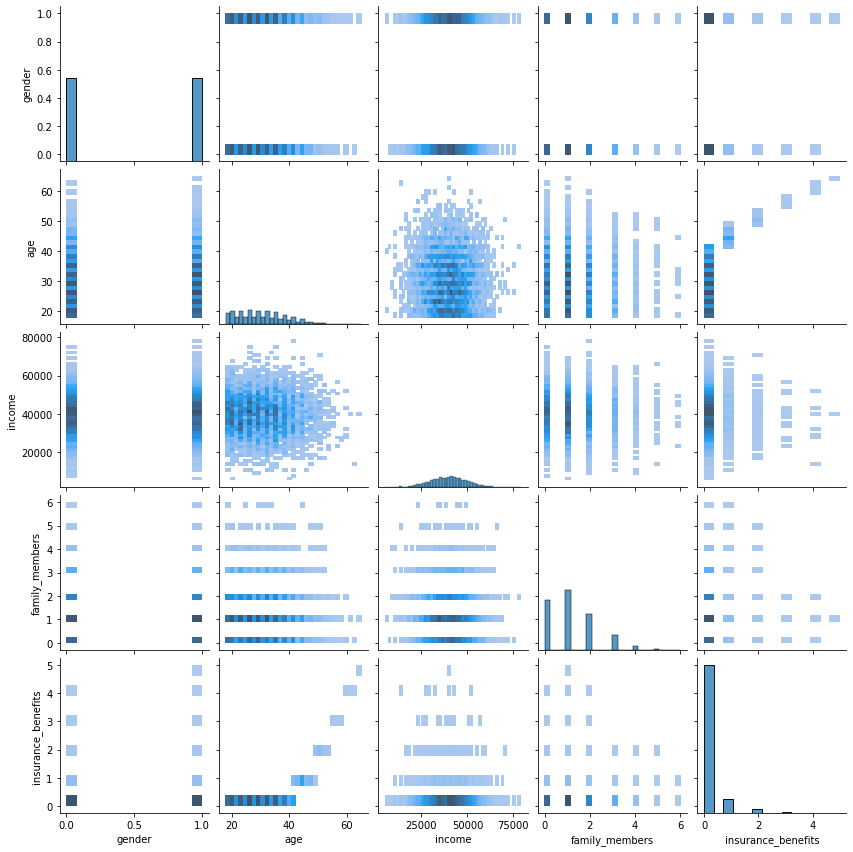

In [12]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, it is a bit difficult to spot obvious groups (clusters) as it is difficult to combine several variables simultaneously (to analyze multivariate distributions). That's where LA and ML can be quite handy.

Let's plot the distribution of column - `age` in the DataFrame:

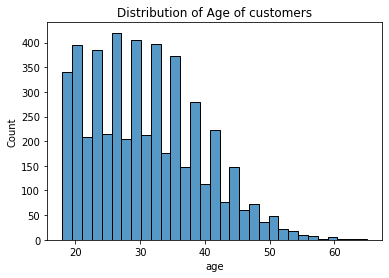

In [13]:
# Plot the distribution of column - age
sns.histplot(data=df['age']).set(title='Distribution of Age of customers')
plt.show()

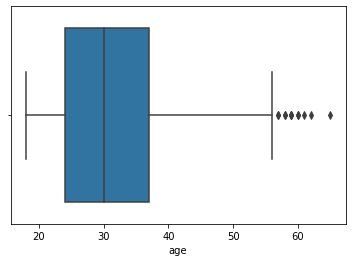

In [14]:
sns.boxplot(x=df['age'])
plt.show()

**The `age` distribution is right-skewed**, with the mean and median around 30, indicates an interesting trend in the dataset. Here's what we can conclude from this information:

- **Skewed Distribution**: A right-skewed distribution, also known as a positively skewed distribution, suggests that **the majority of insured individuals in the dataset are relatively younger**. The skewness is caused by the presence of some older individuals, although they are less frequent compared to the younger ones.

- **Central Tendency**: The fact that the mean (30.95) is greater than the median (30) indicates that the distribution is skewed to the right.

- **Age Range**: The age range in the dataset spans from 18 to 65 years. The presence of individuals as young as 18 and as old as 65 suggests that **the insurance company caters to a diverse age group**.

- **Potential Outliers**: The right-skewed distribution and the box plot also suggest that there are a few older individuals (65 years old) who could be considered as potential outliers.

- **Targeted Strategies**: Knowing that the dataset predominantly contains younger individuals could guide the insurance company's marketing and customer engagement strategies. They might want to focus on tailoring their services to the needs and preferences of this younger demographic.

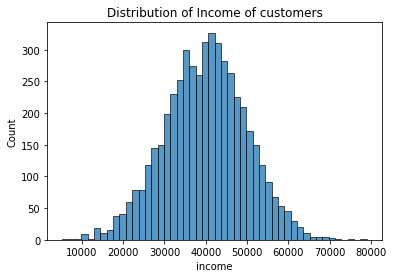

In [15]:
# Plot the distribution of column - income
sns.histplot(data=df['income']).set(title='Distribution of Income of customers')
plt.show()

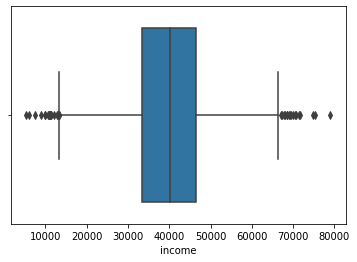

In [16]:
sns.boxplot(x=df['income'])
plt.show()

**The income distribution is approximately normally distributed** around the range of $5,300 to $79,000:

- **Normal Distribution**: The fact that the income distribution is approximately normal indicates that the majority of insured individuals have income levels clustered around the mean, with fewer individuals having extremely high or extremely low incomes.

- **Income Range** : The income range spans from $5,300 to $79,000. This suggests that the insurance company's customers represent a diverse range of income levels.

- **Mean and Median**: If the mean and median are close in value, it implies that the distribution is symmetric.

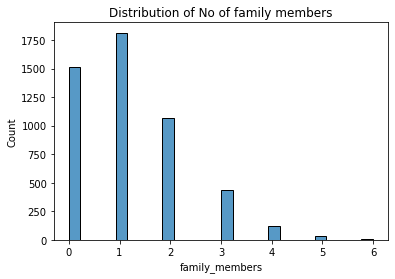

In [17]:
# Plot the distribution of column - family_members
sns.histplot(data=df['family_members']).set(title='Distribution of No of family members')
plt.show()

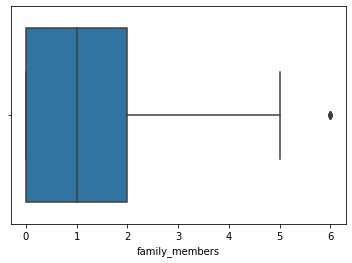

In [18]:
sns.boxplot(x=df['family_members'])
plt.show()

**The distribution of family members is skewed to the right**, with a range of values from 0 to 6, a mean of 1.19, and a median of 1.0, provides us with several conclusions:

- **Skewed Distribution**: A right-skewed distribution indicates that **the majority of insured individuals have a relatively small number of family members**. However, a few individuals have larger family sizes, causing the rightward skewness.

- **Family Size Range**: The range of family sizes spans from 0 (indicating individuals without family members) to 6. This suggests diversity in family structures within the insured population.

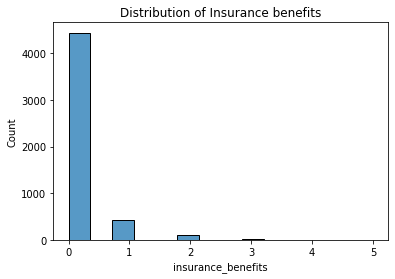

In [19]:
# Plot the distribution of column - insurance_benefits
sns.histplot(data=df['insurance_benefits']).set(title='Distribution of Insurance benefits')
plt.show()

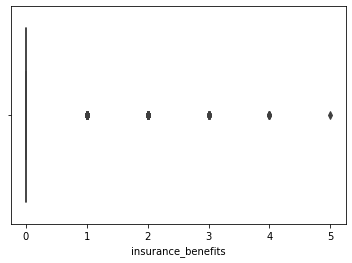

In [20]:
sns.boxplot(x=df['insurance_benefits'])
plt.show()

**The distribution of insurance benefits is heavily skewed to the right**, with a mean of 0.14 and a median of 0, along with a maximum value of 5, provides us with several conclusions:

- **Skewed Distribution**: A heavily right-skewed distribution suggests that **the majority of insured individuals have received very few or no insurance benefits**. This is indicated by the low mean and median values, both being close to 0.

- **Sparse Benefit Recipients**: The fact that the median is 0 implies that at least half of the insured individuals have not received any insurance benefits.

- **Highly Positive Skewness**: The right-skewed nature of the distribution is emphasized by the fact that the maximum value is 5, which is significantly higher than the mean or median. This indicates that a few individuals have received relatively higher numbers of insurance benefits compared to the majority.

- **Data Imbalance**: The skewed distribution might lead to data imbalance issues when developing ML models. This imbalance could affect the models' ability to generalize well to less common scenarios, such as predicting higher numbers of insurance benefits.

# Task 1. Similar Customers <a id='task-1'></a> 
[Back to Contents](#contents)

In the language of ML, it is necessary to develop a procedure that returns k nearest neighbors (objects) for a given object based on the distance between the objects.

We'll write a function that returns k nearest neighbors for an $n^{th}$ object based on a specified distance metric. The number of received insurance benefits should not be taken into account for this task. 

We'll use a ready implementation of the kNN algorithm from scikit-learn (check [the link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)).

And finally we'll test it for four combination of two cases
- **Scaling**
  - the data is not scaled
  - the data is scaled with the [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) scaler
- **Distance Metrics**
  - Euclidean
  - Manhattan

And in the end, we'll try answering these questions on the basis of our observations from the above task:
- Does the data being not scaled affect the kNN algorithm? If so, how does that appear?
- How similar are the results using the Manhattan distance metric (regardless of the scaling)?  

Let's go.

In [21]:
# Get the names of the features
feature_names = ['gender', 'age', 'income', 'family_members']

In [22]:
# Function that returns k nearest neighbors for 𝑛𝑡ℎ object based on a specified distance metric
def get_knn(df, n, k, metric):
    
    """
    Returns k nearest neighbors

    :param df: pandas DataFrame used to find similar objects within
    :param n: object no for which the nearest neighbours are looked for
    :param k: the number of the nearest neighbours to return
    :param metric: name of distance metric
    """

    nbrs = NearestNeighbors(metric=metric)
    nbrs.fit(df[feature_names].values)
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], k, return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res

Great! Now, we'll try to find **10 nearest neighbors** using both **Euclidean** and **Manhattan** distances first for the **unscaled data**. And, for this task, **the object number for which we will look the nearest neighbors for will be 20**. Let's go then:

In [23]:
# Get the 10 nearest neighbors for the object no - 20 using euclidean distance metric
get_knn(df, 20, 10, 'euclidean')

,gender,age,income,family_members,insurance_benefits,distance
20,1,38,43500.0,1,0,0.000000
2058,1,38,43500.0,0,0,1.000000
4927,0,37,43500.0,0,0,1.732051
4219,1,36,43500.0,1,0,2.000000
2309,1,36,43500.0,1,0,2.000000
3721,0,37,43500.0,3,0,2.449490
299,0,39,43500.0,3,0,2.449490
3144,1,41,43500.0,1,0,3.000000
2598,1,35,43500.0,0,0,3.162278
4109,0,35,43500.0,2,0,3.316625


In [24]:
# Get the 10 nearest neighbors for the object no - 20 using manhattan distance metric
get_knn(df, 20, 10, 'manhattan')

,gender,age,income,family_members,insurance_benefits,distance
20,1,38,43500.0,1,0,0.0
2058,1,38,43500.0,0,0,1.0
4219,1,36,43500.0,1,0,2.0
2309,1,36,43500.0,1,0,2.0
4927,0,37,43500.0,0,0,3.0
3144,1,41,43500.0,1,0,3.0
2598,1,35,43500.0,0,0,4.0
3721,0,37,43500.0,3,0,4.0
299,0,39,43500.0,3,0,4.0
4109,0,35,43500.0,2,0,5.0


We can make the following conclusions from the above results of finding the **10 nearest neighbors for the object at index 20 using both Euclidean and Manhattan distance metrics for the unscaled data**:  

**Euclidean Distance Metric Results**:

- The nearest neighbor to the object at index 20 is itself (distance = 0), which is expected since the object is identical to itself.
- The subsequent nearest neighbors have small Euclidean distances, indicating high similarity in terms of the 'age,' 'income,' 'family_members,' and 'insurance_benefits' features.
- The similarity between the object at index 20 and its neighbors decreases as we move further away. This is evident from the increasing distances in the results.  

**Manhattan Distance Metric Results**:

- Similar to the Euclidean metric, the nearest neighbor to the object at index 20 is itself (distance = 0), as it should be.
- The subsequent nearest neighbors also have small Manhattan distances, signifying similarity in the features.
- While the order of the neighbors may vary slightly compared to the Euclidean distance, the general trend of decreasing similarity with increasing distance remains consistent.  

**Overall Conclusions**:

- **Both Euclidean and Manhattan distance metrics produce similar results** for finding the nearest neighbors in this context. This indicates that the choice of distance metric may not have a significant impact on the similarity rankings when the data is unscaled.
- The neighbors found for the object at index 20 appear to have similar characteristics, particularly in terms of age, income, family members, and insurance benefits.
- **Euclidean distances tend to be smaller compared to Manhattan distances for the same pairs of objects**. This is because **Euclidean distance considers the direct path, which is typically shorter than the grid-like (cityblock like) path of Manhattan distance**.
- **For unscaled data**, as in this case, the choice between Euclidean and Manhattan distances can affect **the order of neighbors but typically leads to similar overall conclusions regarding similarity**.

Now, let's scale the data first with the [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) scaler:

In [25]:
# Scale the features with the MaxAbsScaler scaler
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

In [26]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
409,0.0,0.584615,0.686076,0.166667,0
4697,0.0,0.353846,0.377215,0.333333,0
4125,0.0,0.307692,0.525316,0.333333,0
770,1.0,0.723077,0.549367,0.166667,1
1152,0.0,0.430769,0.573418,0.166667,0


Great! Now, since we've scaled the features, let's try to find **10 nearest neighbors** using both **Euclidean** and **Manhattan** distances for this **scaled data**. And, for this task, **the object number for which we will look the nearest neighbors for will be 20**.

In [27]:
# Get the 10 nearest neighbors for the object no - 20 using euclidean distance metric
get_knn(df_scaled, 20, 10, 'euclidean')

,gender,age,income,family_members,insurance_benefits,distance
20,1.0,0.584615,0.550633,0.166667,0,0.000000
4836,1.0,0.584615,0.551899,0.166667,0,0.001266
2575,1.0,0.584615,0.556962,0.166667,0,0.006329
607,1.0,0.584615,0.558228,0.166667,0,0.007595
2315,1.0,0.584615,0.541772,0.166667,0,0.008861
876,1.0,0.584615,0.540506,0.166667,0,0.010127
3461,1.0,0.600000,0.559494,0.166667,0,0.017754
2882,1.0,0.569231,0.535443,0.166667,0,0.021620
1623,1.0,0.584615,0.527848,0.166667,0,0.022785
891,1.0,0.600000,0.568354,0.166667,0,0.023468


In [28]:
# Get the 10 nearest neighbors for the object no - 20 using manhattan distance metric
get_knn(df_scaled, 20, 10, 'manhattan')

,gender,age,income,family_members,insurance_benefits,distance
20,1.0,0.584615,0.550633,0.166667,0,0.000000
4836,1.0,0.584615,0.551899,0.166667,0,0.001266
2575,1.0,0.584615,0.556962,0.166667,0,0.006329
607,1.0,0.584615,0.558228,0.166667,0,0.007595
2315,1.0,0.584615,0.541772,0.166667,0,0.008861
876,1.0,0.584615,0.540506,0.166667,0,0.010127
1623,1.0,0.584615,0.527848,0.166667,0,0.022785
3461,1.0,0.600000,0.559494,0.166667,0,0.024245
2147,1.0,0.584615,0.578481,0.166667,0,0.027848
2882,1.0,0.569231,0.535443,0.166667,0,0.030574


We can make the following conclusions, from the results of finding **the 10 nearest neighbors for the object at index 20 using both Euclidean and Manhattan distance metrics for the scaled data (`MaxAbsScaler`)**:  

**Euclidean Distance Metric Results**:

- As with the unscaled data, the nearest neighbor to the object at index 20 is itself (distance = 0), which is expected.
- The subsequent nearest neighbors also have small Euclidean distances, indicating high similarity in terms of the scaled 'age,' 'income,' 'family_members,' and 'insurance_benefits' features.
- The similarity between the object at index 20 and its neighbors decreases as we move further away.  

**Manhattan Distance Metric Results**:

- Similar to the Euclidean metric, the nearest neighbor to the object at index 20 is itself (distance = 0).
- The subsequent nearest neighbors also have small Manhattan distances, signifying similarity in the scaled features.
- The order of neighbors may vary slightly compared to the Euclidean distance, but the general trend of decreasing similarity with increasing distance remains consistent.  

**Overall Conclusions**:

- **Scaling the data using `MaxAbsScaler` has not significantly altered the conclusions from the unscaled data analysis**. Both Euclidean and Manhattan distance metrics produce similar results for finding the nearest neighbors, indicating that the choice of scaling method did not have a substantial impact on the rankings of nearest neighbors. In this specific dataset and scaling method, the differences between the two metrics remain minimal.

Great! Now, let's try to answer the questions below:

**Does the data being not scaled affect the kNN algorithm? If so, how does that appear?** 

From the observations above, we can say that the scaling of data have a significant impact on the behavior and performance of the k-Nearest Neighbors (kNN) algorithm. In kNN, distances between data points are crucial for determining similarity. When the features have different scales (e.g., one feature ranges from 0 to 1, while another ranges from 0 to 1000), the feature with the larger scale can dominate the distance calculation.
Without scaling, kNN tends to be more sensitive to features with larger scales. Features with smaller scales may have less influence on the distance metric. We can see this evidently in our results above.

**How similar are the results using the Manhattan distance metric (regardless of the scaling)?** 

**The results using the Manhattan distance metric, regardless of scaling, show a high degree of similarity**. In both the unscaled and scaled data analyses, the Manhattan distance metric produced nearly identical rankings for the nearest neighbors. 

# Task 2. Is Customer Likely to Receive Insurance Benefit? <a id='task-2'></a> 
[Back to Contents](#contents)

In terms of machine learning we can look at this like a binary classification task.

With `insurance_benefits` being more than zero as the target, evaluate whether the kNN classification approach can do better than a dummy model.

Lets:
- Build a KNN-based classifier and measure its quality with the F1 metric for k=1..10 for both the original data and the scaled one. That'd be interesting to see how k may influece the evaluation metric, and whether scaling the data makes any difference. You can use a ready implemention of the kNN classification algorithm from scikit-learn (check [the link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) or use your own.
- Build the dummy model which is just random for this case. It should return "1" with some probability. Let's test the model with four probability values: 0, the probability of paying any insurance benefit, 0.5, 1.

The probability of paying any insurance benefit can be defined as

$$
P\{\text{insurance benefit received}\}=\frac{\text{number of clients received any insurance benefit}}{\text{total number of clients}}.
$$

Split the whole data in the 70:30 proportion for the training/testing parts.

In [29]:
# Calculate the target
df['insurance_benefits_received'] = 0
df.loc[df.insurance_benefits != 0, 'insurance_benefits_received'] = 1

In [30]:
# Check for the class imbalance with value_counts()
df['insurance_benefits_received'].value_counts()

0    4436
1     564
Name: insurance_benefits_received, dtype: int64

That's interesting! We have relatively quite less number of values for positive outcomes.

Let's define a function to evaluate a KNN-based classifier that measures the F1 score and confusion matrix:

In [31]:
# Function to evaluate a KNN-based classifier
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
    # if you have an issue with the following line, restart the kernel and run the notebook again
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Confusion Matrix')
    print(cm)

Let's first build the dummy model which is just random for this case. It should return "1" with some probability. 

In [32]:
# generating output of a random model
def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

Let's test the model with four probability values: 0, the probability of paying any insurance benefit, 0.5, 1. 

The probability of paying any insurance benefit can be defined as

$$
P\{\text{insurance benefit received}\}=\frac{\text{number of clients received any insurance benefit}}{\text{total number of clients}}.
$$

In [33]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'The probability: {P:.2f}')
    y_pred_rnd = rnd_model_predict(P, size=len(df))
        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()

The probability: 0.00
F1: 0.00
Confusion Matrix
[[0.8872 0.    ]
 [0.1128 0.    ]]

The probability: 0.11
F1: 0.12
Confusion Matrix
[[0.7914 0.0958]
 [0.0994 0.0134]]

The probability: 0.50
F1: 0.20
Confusion Matrix
[[0.456  0.4312]
 [0.053  0.0598]]

The probability: 1.00
F1: 0.20
Confusion Matrix
[[0.     0.8872]
 [0.     0.1128]]



After testing the dummy model with different probability values, we coudl see that when the probability was set to 0 , the F1 score was 0.00, indicating no predictive power. As the probability increased, the F1 score also increased.
The highest F1 score achieved by the dummy model was 0.20. 

Great! Before proceeding further, let's first split the whole data in the 70:30 proportion for the training/testing parts:

In [34]:
features_train, features_valid, target_train, target_valid = train_test_split(df[feature_names], df.insurance_benefits_received, test_size=0.3, random_state=0)

We're doing good! Now, let's test the ready implemention of the kNN classification algorithm from scikit-learn, for the **unscaled data** and measure its quality with the F1 metric for k=1..10:

In [35]:
for k in range(1,11):
    model = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    model.fit(features_train, target_train)
    pred = model.predict(features_valid)
    print(f'For {k} neighbor(s):')
    eval_classifier(target_valid, pred)
    print()

For 1 neighbor(s):
F1: 0.61
Confusion Matrix
[[0.878      0.01933333]
 [0.04866667 0.054     ]]

For 2 neighbor(s):
F1: 0.44
Confusion Matrix
[[0.89466667 0.00266667]
 [0.07266667 0.03      ]]

For 3 neighbor(s):
F1: 0.44
Confusion Matrix
[[0.88266667 0.01466667]
 [0.07       0.03266667]]

For 4 neighbor(s):
F1: 0.20
Confusion Matrix
[[0.892      0.00533333]
 [0.09066667 0.012     ]]

For 5 neighbor(s):
F1: 0.20
Confusion Matrix
[[0.888      0.00933333]
 [0.09       0.01266667]]

For 6 neighbor(s):
F1: 0.09
Confusion Matrix
[[8.96666667e-01 6.66666667e-04]
 [9.80000000e-02 4.66666667e-03]]

For 7 neighbor(s):
F1: 0.16
Confusion Matrix
[[0.896      0.00133333]
 [0.09333333 0.00933333]]

For 8 neighbor(s):
F1: 0.10
Confusion Matrix
[[8.96666667e-01 6.66666667e-04]
 [9.73333333e-02 5.33333333e-03]]

For 9 neighbor(s):
F1: 0.11
Confusion Matrix
[[8.96666667e-01 6.66666667e-04]
 [9.66666667e-02 6.00000000e-03]]

For 10 neighbor(s):
F1: 0.00
Confusion Matrix
[[0.89733333 0.        ]
 [0.1026

**For the unscaled data, the kNN classifier achieved its best F1 score of 0.61 when considering 1 nearest neighbor**. As k increased, the F1 score generally decreased, indicating that too many neighbors might lower predictive power. The kNN classifier outperformed the dummy model in terms of F1 score across the tested scenarios. It provided better predictive power for identifying individuals likely to receive insurance benefits.

Great! Now, let's scale the data now using `MaxAbsScaler()`:

In [36]:
# Scale the data using MaxAbsScaler
transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(features_train.to_numpy())

features_train[feature_names] = transformer_mas.transform(features_train.to_numpy())
features_valid[feature_names] = transformer_mas.transform(features_valid.to_numpy())

Now, let's test the ready implemention of the kNN classification algorithm from scikit-learn, for the **scaled data** and measure its quality with the F1 metric for k=1..10:

In [37]:
for k in range(1,11):
    model = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    model.fit(features_train, target_train)
    pred = model.predict(features_valid)
    print(f'For {k} neighbor(s):')
    eval_classifier(target_valid, pred)
    print()

For 1 neighbor(s):
F1: 0.95
Confusion Matrix
[[0.89466667 0.00266667]
 [0.00666667 0.096     ]]

For 2 neighbor(s):
F1: 0.92
Confusion Matrix
[[0.89733333 0.        ]
 [0.01466667 0.088     ]]

For 3 neighbor(s):
F1: 0.94
Confusion Matrix
[[0.89533333 0.002     ]
 [0.01       0.09266667]]

For 4 neighbor(s):
F1: 0.89
Confusion Matrix
[[0.89733333 0.        ]
 [0.02       0.08266667]]

For 5 neighbor(s):
F1: 0.91
Confusion Matrix
[[0.89533333 0.002     ]
 [0.016      0.08666667]]

For 6 neighbor(s):
F1: 0.89
Confusion Matrix
[[0.89533333 0.002     ]
 [0.01933333 0.08333333]]

For 7 neighbor(s):
F1: 0.91
Confusion Matrix
[[0.89466667 0.00266667]
 [0.014      0.08866667]]

For 8 neighbor(s):
F1: 0.89
Confusion Matrix
[[0.896      0.00133333]
 [0.01866667 0.084     ]]

For 9 neighbor(s):
F1: 0.91
Confusion Matrix
[[0.89466667 0.00266667]
 [0.01533333 0.08733333]]

For 10 neighbor(s):
F1: 0.90
Confusion Matrix
[[0.896      0.00133333]
 [0.018      0.08466667]]



**The kNN classifier achieved high F1 scores across all values of k, ranging from 0.89 to 0.95**.The best F1 score of 0.95 was obtained when considering only the nearest neighbor (k=1).As k increased, the F1 scores remained relatively high, indicating that the classifier maintained strong predictive power even when considering more neighbors.  

**Scaling the data using MaxAbsScaler significantly improved the performance of the kNN classifier compared to the unscaled data**. This demonstrates the importance of feature scaling in kNN when features have different scales.

# Task 3. Regression (with Linear Regression) <a id='task-3'></a> 
[Back to Contents](#contents)

With `insurance_benefits` as the target, let's evaluate what RMSE would be for a Linear Regression model.

We'll build our own implementation of LR. We'll check RMSE for both the original data and the scaled one and check any difference in RMSE between these two cases.

Let's denote
- $X$ — feature matrix, each row is a case, each column is a feature, the first column consists of unities
- $y$ — target (a vector)
- $\hat{y}$ — estimated tagret (a vector)
- $w$ — weight vector

The task of linear regression in the language of matrices can be formulated as

$$
y = Xw
$$

The training objective then is to find such $w$ that it would minimize the L2-distance (MSE) between $Xw$ and $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

It appears that there is analytical solution for the above:

$$
w = (X^T X)^{-1} X^T y
$$

The formula above can be used to find the weights $w$ and the latter can be used to calculate predicted values

$$
\hat{y} = X_{val}w
$$

We'll split the whole data in the 70:30 proportion for the training/validation parts and use the RMSE metric for the model evaluation.

Let's first build our own implementation of Linear Regression model:

In [38]:
class MyLinearRegression:
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(X2.T.dot(X2)).dot(X2.T).dot(y)

    def predict(self, X):
        
        # adding the unities
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2.dot(self.weights)
        
        return y_pred

Let's define a function to evaluate our model that measures the RMSE and R2 scores:

In [39]:
def eval_regressor(y_true, y_pred):
    
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')
    
    r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')    

Let's **predict the `insurance_benefits` for the unscaled data** first using our implementation of Linear Regression model:

In [40]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
RMSE: 0.34
R2: 0.66


Now let's **predict the `insurance_benefits` for the scaled data** first using our implementation of Linear Regression model:

In [41]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(X_train)

X_train = transformer_mas.transform(X_train)
X_test = transformer_mas.transform(X_test)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-0.94353901  2.32372069  0.01642727 -0.02059875 -0.07014128]
RMSE: 0.34
R2: 0.66


- **Weights**: The weight of the LR model differ between the unscaled and scaled data. This is expected because the scaling process changes the scale of the features, which can impact the magnitude of weights.

- **RMSE**: The RMSE for both the unscaled and scaled data is identical at 0.34.

- **R2 Score**: The R2 score is also the same at 0.66 for both the unscaled and scaled data. This indicates that the LR models explain approximately 66% of the variance in `insurance_benefits` for both datasets.

- **Scaling Impact**: In this specific case, **scaling the data did not result in a significant difference in RMSE or R2 score for the LR model**.

# Task 4. Obfuscating Data <a id='task-4'></a> 
[Back to Contents](#contents)

It best to obfuscate data by multiplying the numerical features (remember, they can be seen as the matrix $X$) by an invertible matrix $P$. 

$$
X' = X \times P
$$

Let's try to do that and check how the features' values will look like after the transformation. By the way, the intertible property is important here so make sure that $P$ is indeed invertible.

In [42]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]
df_pn.head()

,gender,age,income,family_members
0,1,41,49600.0,1
1,0,46,38000.0,1
2,0,29,21000.0,0
3,0,21,41700.0,2
4,1,28,26100.0,0


In [43]:
X = df_pn.to_numpy()

Generating a random matrix $P$.

In [44]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))
P

array([[0.77395605, 0.43887844, 0.85859792, 0.69736803],
       [0.09417735, 0.97562235, 0.7611397 , 0.78606431],
       [0.12811363, 0.45038594, 0.37079802, 0.92676499],
       [0.64386512, 0.82276161, 0.4434142 , 0.22723872]])

Checking the matrix $P$ is invertible and if so, get its inverse:

In [45]:
# get inverse of P
P_inv = np.linalg.inv(P)
P_inv

array([[ 0.41467992, -1.43783972,  0.62798546,  1.14001268],
       [-1.06101789,  0.44219337,  0.1329549 ,  1.18425933],
       [ 1.42362442,  1.60461607, -2.0553823 , -1.53699695],
       [-0.11128575, -0.65813802,  1.74995517, -0.11816316]])

Let's get the new obfuscated dataset:

In [46]:
# Get the new obfuscated dataset
X_new = X @ P
X_new

array([[ 6359.71527314, 22380.40467609, 18424.09074184, 46000.69669016],
       [ 4873.29406479, 17160.36702982, 14125.78076133, 35253.45577301],
       [ 2693.11742928,  9486.397744  ,  7808.83156024, 19484.86063067],
       ...,
       [ 4346.2234249 , 15289.24126492, 12586.16264392, 31433.50888552],
       [ 4194.09324155, 14751.9910242 , 12144.02930637, 30323.88763426],
       [ 5205.46827354, 18314.24814446, 15077.01370762, 37649.59295455]])

**Can you guess the customers' ages or income after the transformation?**

No, it is not posssible to guess customers' ages or income after transformation.

**Can you recover the original data from $X'$ (i.e. `X_new`) if you know $P$? Try to check that with calculations by moving $P$ from the right side of the formula above to the left one. The rules of matrix multiplcation are really helpful here.**

$$
X' = X \times P
$$
Multiply $P^{-1}$ to both sides:
$$
X' \times P^{-1} = X \times P \times P^{-1}
$$
$P$ $\times$ $P^{-1}$ = $I$ (identity matrix), thus:
$$
X' \times P^{-1} = X
$$

Let's do the same to recover the original data - `X` from `X_new` and `P_inv`:

In [47]:
X_recovered = X_new @ P_inv
X_recovered

array([[ 1.00000000e+00,  4.10000000e+01,  4.96000000e+04,
         1.00000000e+00],
       [-4.47363596e-12,  4.60000000e+01,  3.80000000e+04,
         1.00000000e+00],
       [-2.51586878e-12,  2.90000000e+01,  2.10000000e+04,
         9.52452315e-13],
       ...,
       [-1.92837871e-12,  2.00000000e+01,  3.39000000e+04,
         2.00000000e+00],
       [ 1.00000000e+00,  2.20000000e+01,  3.27000000e+04,
         3.00000000e+00],
       [ 1.00000000e+00,  2.80000000e+01,  4.06000000e+04,
         1.00000000e+00]])

Print all three cases for a few customers
- The original data
- The transformed one
- The reversed (recovered) one

In [48]:
print(f'Original data:\n {X}')
print()
print(f'Transformed data:\n {X_new}')
print()
print(f'Recovered data:\n {X_recovered}')

Original data:
 [[1.00e+00 4.10e+01 4.96e+04 1.00e+00]
 [0.00e+00 4.60e+01 3.80e+04 1.00e+00]
 [0.00e+00 2.90e+01 2.10e+04 0.00e+00]
 ...
 [0.00e+00 2.00e+01 3.39e+04 2.00e+00]
 [1.00e+00 2.20e+01 3.27e+04 3.00e+00]
 [1.00e+00 2.80e+01 4.06e+04 1.00e+00]]

Transformed data:
 [[ 6359.71527314 22380.40467609 18424.09074184 46000.69669016]
 [ 4873.29406479 17160.36702982 14125.78076133 35253.45577301]
 [ 2693.11742928  9486.397744    7808.83156024 19484.86063067]
 ...
 [ 4346.2234249  15289.24126492 12586.16264392 31433.50888552]
 [ 4194.09324155 14751.9910242  12144.02930637 30323.88763426]
 [ 5205.46827354 18314.24814446 15077.01370762 37649.59295455]]

Recovered data:
 [[ 1.00000000e+00  4.10000000e+01  4.96000000e+04  1.00000000e+00]
 [-4.47363596e-12  4.60000000e+01  3.80000000e+04  1.00000000e+00]
 [-2.51586878e-12  2.90000000e+01  2.10000000e+04  9.52452315e-13]
 ...
 [-1.92837871e-12  2.00000000e+01  3.39000000e+04  2.00000000e+00]
 [ 1.00000000e+00  2.20000000e+01  3.27000000e+04

**You can probably see that some values are not exactly the same as they are in the original data. What might be the reason for that?**

While some of the values may not be precisely identical, they are exceptionally close. Notably, values that were initially zero are now represented as extremely small numbers, but these minute discrepancies might would have stemed from the intricacies of computer calculations and floating point numbers precesions.

## Proof That Data Obfuscation Can Work with LR

The regression task has been solved with linear regression in this project. Your next task is to prove _analytically_ that the given obfuscation method won't affect linear regression in terms of predicted values i.e. their values will remain the same. Can you believe that? Well, you don't have to, you should prove it!

So, the data is obfuscated and there is $X \times P$ instead of just $X$ now. Consequently, there are other weights $w_P$ as
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

How would $w$ and $w_P$ be linked if you simplify the formula for $w_P$ above? 

What would be predicted values with $w_P$? 

What does that mean for the quality of linear regression if you measure it with RMSE?

Check Appendix B Properties of Matrices in the end of the notebook. There are useful formulas in there!

No code is necessary in this section, only analytical explanation!

**Analytical proof**

$$
y = Xw
$$
$$
w_P = [(XP)^T XP]^{-1} (XP)^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T Xw
$$
$$
w_P = [(P^TX^T) (XP)]^{-1} P^TX^T Xw \quad \Rightarrow \quad w_P = (XP)^{-1}(P^TX^T)^{-1}  P^TX^T Xw
$$
$$
w_P = P^{-1}X^{-1}{X^T}^{-1}{P^T}^{-1}  P^TX^T Xw \quad \Rightarrow \quad w_P = P^{-1}X^{-1}{X^T}^{-1}X^T Xw
$$
$$
w_P = P^{-1}w
$$
$$
P w_p = w
$$

The formula to calculate predicted values with $w_p$ in the obfuscated data is:

$$
\hat{y}_p = (XP)w_p
$$

Substitute $w_p = P^{-1}w$

$$
\hat{y}_p = XPP^{-1}w
$$
$$
\hat{y}_p = Xw
$$

Thus, $\hat{y}_p = Xw = y$

**Answer**

The predicted values with $w_p$ remain identical when $\hat{y}_p = y$. This implies that the predictions from the obfuscated data match those from the unmasked data. Because the predictions are identical, the Root Mean Squared Error (RMSE) will also remain the same.

## Test Linear Regression With Data Obfuscation

Now, let's prove Linear Regression can work computationally with the chosen obfuscation transformation.

Build a procedure or a class that runs Linear Regression optionally with the obfuscation. You can use either a ready implementation of Linear Regression from sciki-learn or your own.

Run Linear Regression for the original data and the obfuscated one, compare the predicted values and the RMSE, $R^2$ metric values. Is there any difference?

**Procedure**

- Create a square matrix $P$ of random numbers.
- Check that it is invertible. If not, repeat the first point until we get an invertible matrix.
- Import linear regression models
- Use $XP$ as the new feature matrix
- Split training/testing 70/30 and compare between $X$ and $XP$ features

In [49]:
# Make original data
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]
df_pn.head()

,gender,age,income,family_members
0,1,41,49600.0,1
1,0,46,38000.0,1
2,0,29,21000.0,0
3,0,21,41700.0,2
4,1,28,26100.0,0


In [50]:
X = df_pn.to_numpy()
X

array([[1.00e+00, 4.10e+01, 4.96e+04, 1.00e+00],
       [0.00e+00, 4.60e+01, 3.80e+04, 1.00e+00],
       [0.00e+00, 2.90e+01, 2.10e+04, 0.00e+00],
       ...,
       [0.00e+00, 2.00e+01, 3.39e+04, 2.00e+00],
       [1.00e+00, 2.20e+01, 3.27e+04, 3.00e+00],
       [1.00e+00, 2.80e+01, 4.06e+04, 1.00e+00]])

In [51]:
Y = df['insurance_benefits'].to_numpy()
Y

array([0, 1, 0, ..., 0, 0, 0])

In [52]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))
P

array([[0.77395605, 0.43887844, 0.85859792, 0.69736803],
       [0.09417735, 0.97562235, 0.7611397 , 0.78606431],
       [0.12811363, 0.45038594, 0.37079802, 0.92676499],
       [0.64386512, 0.82276161, 0.4434142 , 0.22723872]])

In [53]:
# Check if P is invertible
np.linalg.inv(P)

array([[ 0.41467992, -1.43783972,  0.62798546,  1.14001268],
       [-1.06101789,  0.44219337,  0.1329549 ,  1.18425933],
       [ 1.42362442,  1.60461607, -2.0553823 , -1.53699695],
       [-0.11128575, -0.65813802,  1.74995517, -0.11816316]])

In [54]:
# Get the new obfuscated dataset
X_new = X @ P
X_new

array([[ 6359.71527314, 22380.40467609, 18424.09074184, 46000.69669016],
       [ 4873.29406479, 17160.36702982, 14125.78076133, 35253.45577301],
       [ 2693.11742928,  9486.397744  ,  7808.83156024, 19484.86063067],
       ...,
       [ 4346.2234249 , 15289.24126492, 12586.16264392, 31433.50888552],
       [ 4194.09324155, 14751.9910242 , 12144.02930637, 30323.88763426],
       [ 5205.46827354, 18314.24814446, 15077.01370762, 37649.59295455]])

In [55]:
# Confirm data obfuscation
print(f'Non-obfuscated data:\n {X}')
print()
print(f'Obfuscated data:\n {X_new}')

Non-obfuscated data:
 [[1.00e+00 4.10e+01 4.96e+04 1.00e+00]
 [0.00e+00 4.60e+01 3.80e+04 1.00e+00]
 [0.00e+00 2.90e+01 2.10e+04 0.00e+00]
 ...
 [0.00e+00 2.00e+01 3.39e+04 2.00e+00]
 [1.00e+00 2.20e+01 3.27e+04 3.00e+00]
 [1.00e+00 2.80e+01 4.06e+04 1.00e+00]]

Obfuscated data:
 [[ 6359.71527314 22380.40467609 18424.09074184 46000.69669016]
 [ 4873.29406479 17160.36702982 14125.78076133 35253.45577301]
 [ 2693.11742928  9486.397744    7808.83156024 19484.86063067]
 ...
 [ 4346.2234249  15289.24126492 12586.16264392 31433.50888552]
 [ 4194.09324155 14751.9910242  12144.02930637 30323.88763426]
 [ 5205.46827354 18314.24814446 15077.01370762 37649.59295455]]


Let's evaluate linear regression model on original data:

In [56]:
# Evaluate linear regression model on original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()
lr.fit(X_train, y_train)

y_test_pred = lr.predict(X_test)

eval_regressor(y_test, y_test_pred)

RMSE: 0.34
R2: 0.66


Let's evaluate linear regression model on obfuscated data:

In [57]:
# Evaluate linear regression model on obfuscated data
X_train_obfuscated, X_test_obfuscated, y_train_obfuscated, y_test_obfuscated = train_test_split(X_new, y, test_size=0.3, random_state=12345)

lr_obfuscated = MyLinearRegression()
lr_obfuscated.fit(X_train_obfuscated, y_train_obfuscated)

y_test_pred_obfuscated = lr_obfuscated.predict(X_test_obfuscated)

eval_regressor(y_test_obfuscated, y_test_pred_obfuscated)

RMSE: 0.34
R2: 0.66


There is no distinction between the RMSE and R2 score when comparing obfuscated features to non-obfuscated features. They are identical!

# Conclusions <a id='conclusions'></a> 
[Back to Contents](#contents)

We wrote a function that returns k nearest neighbors for an 𝑛𝑡ℎ object based on a specified distance metric. And we testest it for four combination of two cases
- **Scaling**
  - the data is not scaled
  - the data is scaled with the [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) scaler
- **Distance Metrics**
  - Euclidean
  - Manhattan

In kNN, distances between data points are crucial for determining similarity. When the features have different scales (e.g., one feature ranges from 0 to 1, while another ranges from 0 to 1000), the feature with the larger scale can dominate the distance calculation. Without scaling, kNN tends to be more sensitive to features with larger scales. Features with smaller scales may have less influence on the distance metric. We can see this evidently in our results above. The results using the Manhattan distance metric, regardless of scaling, show a high degree of similarity. 

We also built a KNN-based classifier and measure its quality with the F1 metric for k=1..10 for both the original data and the scaled one. Scaling the data using MaxAbsScaler significantly improved the performance of the kNN classifier compared to the unscaled data. This demonstrates the importance of feature scaling in kNN when features have different scales.

We also build our own implementation of LR and RMSE for both the original data and the scaled one and checked any difference in RMSE between these two cases. In this specific case, scaling the data did not result in a significant difference in RMSE or R2 score for the LR model.

We also obfuscated the data and figured out that it is not posssible to guess customers' ages or income after transformation. We also proved that Data Obfuscation can work with LR and tested Linear Regression With Data Obfuscation. And proved that there is no distinction between the RMSE and R2 score when comparing obfuscated features to non-obfuscated features. They are identical!

# Appendices 

## Appendix A: Writing Formulas in Jupyter Notebooks

You can write formulas in your Jupyter Notebook in a markup language provided by a high-quality publishing system called $\LaTeX$ (pronounced "Lah-tech"), and they will look like formulas in textbooks.

To put a formula in a text, put the dollar sign (\\$) before and after the formula's text e.g. $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

If a formula should be in its own paragraph, put the double dollar sign (\\$\\$) before and after the formula text e.g.

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

The markup language of [LaTeX](https://en.wikipedia.org/wiki/LaTeX) is very popular among people who use formulas in their articles, books and texts. It can be complex but its basics are easy. Check this two page [cheatsheet](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) for learning how to compose the most common formulas.

## Appendix B: Properties of Matrices

Matrices have many properties in Linear Algebra. A few of them are listed here which can help with the analytical proof in this project.

<table>
<tr>
<td>Distributivity</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>Non-commutativity</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Associative property of multiplication</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Multiplicative identity property</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversivity of the transpose of a product of matrices,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>